# Overviews (image pyramids)

Overviews are down-sampled copies of a raster stored alongside the full-resolution data, so a
viewer can read a coarse level when zoomed out instead of the whole array — the *pyramid* the
package is named for.

- **`create_overviews`** — build the pyramid levels.
- **`overview_count`** — how many levels each band has.
- **`get_overview`** — fetch one level as a GDAL band.

## Setup

In [1]:
%matplotlib inline

import shutil
import tempfile
from pathlib import Path

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-t2-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset

# Copy to scratch first — create_overviews writes the pyramids into the file.
src = WORK / 'dem.tif'
shutil.copy(DATA / 'dem' / 'DEM5km_Rhine_burned_acc.tif', src)
ds = Dataset.read_file(src)
ds.shape, ds.overview_count

((1, 125, 93), [0])

The full-resolution DEM — the base level of the pyramid we are about to build.

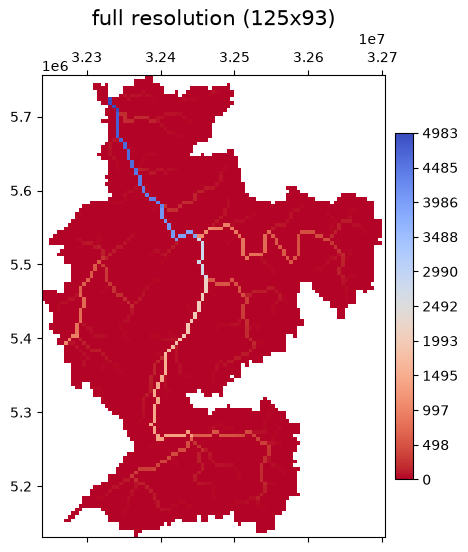

In [3]:
ds.plot(band=0, title="full resolution (125x93)")

## Build the pyramid — `create_overviews`

Pick a resampling method (`'average'`, `'nearest'`, `'cubic'`, …).

In [4]:
ds.create_overviews(resampling_method='average')
ds.overview_count  # levels per band

[7]

## Read a level — `get_overview`

Level 0 is the coarsest; each level halves the resolution.

In [5]:
ov = ds.get_overview(band=0, overview_index=0)
full = ds.shape
full, '->', (ov.XSize, ov.YSize)

((1, 125, 93), '->', (47, 63))

A pyramid level is just a down-sampled copy of the base. Resampling the DEM to the coarsest level's
cell size shows what that stored overview looks like — the same terrain, far fewer pixels.

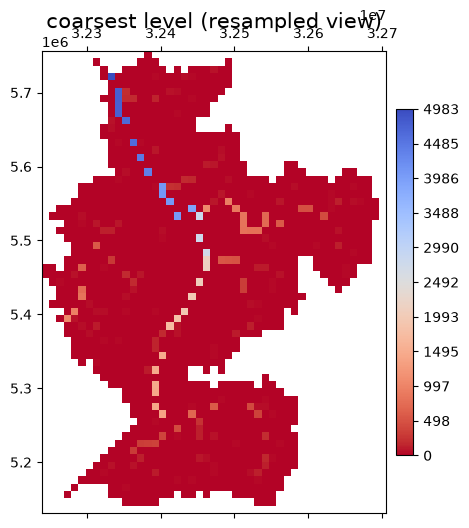

In [6]:
coarse = ds.resample(cell_size=ds.cell_size * (ds.shape[1] / ov.YSize))
coarse.plot(band=0, title="coarsest level (resampled view)")

## Notes

- More levels = faster zoomed-out reads, slightly larger files.
- Cloud Optimized GeoTIFFs bake overviews into the file on write — see the COG tutorial.
- See also: [Visualization](visualization.ipynb) (the `plot(overview=True)` option).